# Module 3.3 — Notebook B: Improve the baseline

In Notebook A you measured the baseline and found where it falls short: routing quality landed below the bar, and the department confusion matrix showed specific pairs being mixed up. This notebook picks up that story and tests whether you can close the gap.

You will try two practical levers: **prompt design** and **few-shot examples**. Each is tested against the same baseline — same model, same data — so the results are directly comparable.

The goal is not a perfect score. The goal is to understand what actually moves the metrics — and at what cost in latency and spend.

## What this notebook explores

This notebook focuses on **improvement**, not initial validation.

1. **Prompt refinement** — Can clearer instructions improve routing quality?
2. **Few-shot learning** — Do labeled examples help the model route better?
3. **Trade-offs** — Do these improvements change cost or latency?
4. **Diagnostics** — Where does the model still confuse departments, and why?

Assume you have completed Notebook A (or at least have a comparable baseline). You’ll use the **same dataset and model**, and compare every change to that reference.

## Step 1 - Setup

### Install dependencies

Run the cell bellow to install dependencies and load helpers.

In [ ]:
%pip install -q git+https://github.com/mnrozhkov/ai_leader.git --upgrade
%matplotlib inline

import os

from dotenv import load_dotenv

from ai_leader import *

load_dotenv(override=False)

True

### API key & parameters

Set your Nebius TokenFacotry API key and experiment parameters below.

This notebook calls the **Nebius inference API** (OpenAI-compatible).
Get your key at [Nebius AI Studio](https://studio.nebius.ai) → Settings → API Keys.
Store it as a Colab Secret named `NEBIUS_API_KEY`

Troubleshooting:
- if you see **401 error**: Make sure you use a Nebius *inference* API key (not an OpenAI key). See [Nebius API authentication](https://docs.nebius.com/studio/api/authentication) for regional endpoint options.

In [2]:
api_key = setup_api_key()

# Example dataset
DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

API key configured (***W1cB)


### Load the evaluation dataset

The CSV holds labeled customer requests with **gold routing targets** (department, category, etc.). We use it to measure how the routing prototype performs beyond a handful of ad-hoc examples.

**Where the file comes from:** the path is set in the previous cell as `DATASET_URL`. By default that is a published Google Sheet CSV URL.

If loading fails, the next cell raises a short error that repeats the URL or path you tried.

In [3]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


## Step 2 — Baseline reference run

First, reproduce the Notebook A baseline: the model you selected there, run with the **default prompt**. This is the reference point every later change is measured against.

Recall what Notebook A found at this baseline: routing **quality failed** — department accuracy landed well below the 85% target, and the confusion matrix showed *Customer Support* being over-predicted at the expense of neighbouring departments. Keep that gap in mind — Steps 3 and 4 each try to close it.


Set `MODEL_TO_EVALUATE` to the model you selected in Notebook A (Step 4). The default below is the suggested model from the comparison run — update it if your evaluation pointed elsewhere.

Using the same model as Notebook A is important: it ensures that any accuracy change in this notebook comes from prompt or data changes, not from switching models.

In [4]:
# Best model from Notebook A — change if your evaluation picked a different one
MODEL_TO_EVALUATE = "openai/gpt-oss-120b"
client = create_client(api_key, model=MODEL_TO_EVALUATE)

# Run model evaluation (on the default prompt)
baseline_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

Check the baseline results before changing anything. Note which dimensions fail — that tells you which improvement to try first.

In [5]:
baseline_decision = evaluate_decision(baseline_run)
display_mvp_decision(decision=baseline_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.580,0.85
1,Category Accuracy,fail,0.670,0.85
2,Unsafe Auto Route Rate,fail,0.380,0.03
3,Monthly Cost Usd,pass,3.372,1000.00
4,P95 Latency Ms,pass,1174.252,5000.00


The baseline decision table shows where the gaps are. Note which dimensions fail before moving on — this determines which step in this notebook to focus on first. Possible scenarios:

- Quality fails → Step 3 (prompt improvement) is the highest-leverage next action, followed by Step 4 (few-shot examples).
- Safety fails → the model's confidence is poorly calibrated; inspect the high-confidence errors surfaced in the department mistakes tables (Steps 3 and 4) before trusting auto-routing.
- Cost fails → a lighter model is worth testing; this notebook does not cover model swaps, but the comparison setup from Notebook A Step 3 can be reused.
- Speed fails → check whether a smaller model from the Notebook A shortlist has lower latency before adding prompt length or examples.

## Step 3 — Improve the prompt

Can a better prompt improve routing quality? We run the **improved prompt** on the same data and model, then compare it to the baseline.

Any change in accuracy, safety, or cost is attributable to the prompt alone — everything else stays fixed.

### What changed in the improved prompt, and why

The default prompt only states the output schema — it never tells the model *what the departments mean* or *how to choose between them*. The improved prompt below adds exactly the context that was missing in Notebook A. Each addition targets a specific failure from the baseline:

| Added to the prompt | Why it should improve quality |
| --- | --- |
| **Company context** (Candlekeep, channels, volume) | Grounds the model in the domain so ambiguous messages are read in the right context. |
| **Explicit category definitions** | Removes guesswork about what counts as Payment vs Order Issue vs Delivery vs General Feedback. |
| **Department routing rules** | Maps each category to a department using the **exact label names from the dataset**, so correct answers are not lost to naming mismatches. |
| **"Key distinctions" for edge cases** | Directly attacks the confusion pairs from the baseline matrix: a *charge* dispute → Customer Support vs a *damaged item* → Returns, bulk-pricing → Product Team, delivery-window complaints → Logistics. |
| **Confidence definitions** | Calibrates High/Medium/Low so the safety guardrail is meaningful instead of confident-by-default. |

The **output schema is unchanged**, so the comparison isolates the effect of the added guidance — not a different response format. Read the prompt below, then run it.

In [6]:
# Improved prompt, built from the insights found in Notebook A.
# Edit it to test your own ideas — the summary above explains each addition.

IMPROVED_SYSTEM_PROMPT = """
You are the AI routing assistant for Candlekeep, an e-commerce company that receives
10,000+ customer messages per month across email, chat, phone, and social channels.

Your task: classify each customer message and route it to the correct department.

## Categories
- **Payment** — refunds, charges, billing disputes, payment method updates
- **Order Issue** — damaged items, missing parts, wrong items, exchanges, returns
- **Delivery** — shipping delays, address changes, tracking, delivery window issues
- **General Feedback** — product praise/complaints, suggestions, bulk-order inquiries,
  non-order-specific questions

## Departments and routing rules
- **Customer Support** — handles Payment issues (refunds, billing, charges)
- **Returns** — handles Order Issue cases (damaged, missing parts, exchanges, wrong items)
- **Logistics** — handles Delivery problems (shipping, tracking, address changes)
- **Product Team** — handles General Feedback (product feedback, feature requests, suggestions)

## Key distinctions
- A billing complaint about a *charge* goes to Customer Support, not Returns.
- A complaint about a *damaged item* goes to Returns, not Customer Support.
- "Bulk order pricing" is General Feedback → Product Team, not Payment → Customer Support.
- Delivery-window complaints go to Logistics even if an order is involved.

## Confidence
- **High** — the category and department are clearly indicated by the message
- **Medium** — plausible but the message is ambiguous or could fit multiple categories
- **Low** — very uncertain; the message is vague or unusual

Return a JSON object with exactly these keys:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)

Do not add extra keys.
"""

In [7]:
# Run experiment with a new prompt
improved_prompt_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [8]:
# Display metrics
improved_prompt_decision = evaluate_decision(improved_prompt_run)
display_mvp_decision(decision=improved_prompt_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.730,0.85
1,Category Accuracy,pass,0.860,0.85
2,Unsafe Auto Route Rate,fail,0.240,0.03
3,Monthly Cost Usd,pass,4.661,1000.00
4,P95 Latency Ms,pass,1601.473,5000.00


In [9]:
# Compare 'Improved prompt' experiment results with a 'baseline'
_ = display_run_comparison_table(
    baseline=baseline_run,
    new=improved_prompt_run,
    eval_df=df,
    new_label="Improved prompt",
    show_all=False,
)

,baseline,Improved prompt,delta_vs_baseline
department_accuracy,0.58,0.73,0.15
category_accuracy,0.67,0.86,0.19
unsafe_auto_route_rate,0.38,0.24,-0.14
monthly_cost_usd,3.372,4.661,1.289
p95_latency_ms,1174.252,1601.473,427.221


The comparison table shows the effect of the prompt change in isolation — same model, same data, different instructions. Read it in this order:

1. **Department accuracy delta** — did routing improve, and by how much? A gain of 10+ percentage points is meaningful; a gain of 1–2% may be within noise.
2. **Unsafe auto-route rate delta** — did safety improve alongside accuracy? If accuracy went up but unsafe auto-route rate also went up, the prompt is producing more confident but less reliable outputs — inspect the department confusion matrix and mistakes table below before keeping the change.
3. **Cost and latency delta** — a longer prompt will almost always increase both slightly. This is acceptable if the accuracy gain is proportional. If cost or latency more than doubles with a small accuracy gain, the trade-off is not worth it.

The pattern to look for is accuracy and safety improving *together* while cost and latency rise only marginally — that means the added guidance is doing real work without an unacceptable overhead. Keep in mind that model outputs vary from run to run, so a small delta (a point or two) may just be noise; re-run before trusting it.

If your results show a clear accuracy gain, keep the prompt and move to Step 4. If the gain is small or safety regresses, return to the prompt and tighten the label definitions further before adding examples.

category_accuracy           0.860
category_f1_macro           0.859
department_accuracy         0.730
department_f1_macro         0.727
exact_route_match_rate      0.720
misroute_rate               0.270
row_count                 100.000


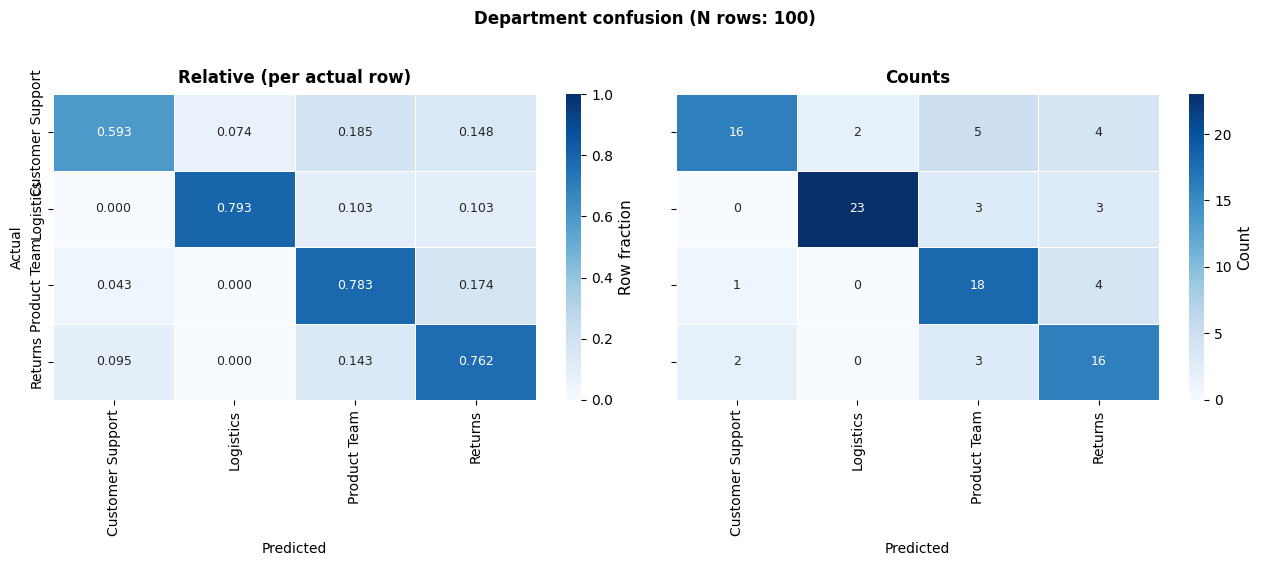

,Request Text,Department,Predicted Department
4,The toaster oven sparked when I plugged it in....,Product Team,Returns
8,Instructions for the Lumina lamp are missing f...,Product Team,Returns
13,Website is crashing on the payment screen.,Product Team,Customer Support
19,I am going to sue your company if you don't fi...,Logistics,Returns
26,Package in rain rug ruined.,Logistics,Returns
29,Talk to manager now. Support is useless.,Logistics,Product Team
32,No refund received for return CK-9944.,Returns,Customer Support
35,Order canceled without my permission.,Customer Support,Returns
37,Add one more lamp to order CK-1100.,Customer Support,Returns
40,Received two lamps only ordered one.,Customer Support,Returns


In [11]:
# Department confusion + sample mistakes for the improved prompt
improved_mistakes = display_evaluation_with_department_mistakes(
    eval_results=improved_prompt_run,
    eval_df=df,
    # max_rows=10,
    show_category_confusion=False,
)
improved_mistakes

Compare this department confusion matrix to the baseline from Step 2. The improved prompt should shrink the off-diagonal cells for the pairs the "Key distinctions" section targets — for example, charge disputes that were landing in *Returns* should now route to *Customer Support*.

Read it like this:

- **Did department accuracy clear the 85% target?** If so, the prompt change alone may already meet the routing goal.
- **Which pairs still dominate the mistakes table?** Step 4 tries a *different* lever — few-shot examples on the original default prompt — so you can compare which approach handles these confusions better.

## Step 4 — Few-shot trade-offs

Do labeled examples in the prompt help? We run the same model with increasing numbers of few-shot examples and compare quality, cost, and latency.

The ablation runs on the **same default prompt as the Step 2 baseline** — not the improved prompt. That keeps few-shot as an *independent* lever: any gain here is measured against the baseline, just like the prompt-improvement gain in Step 3, so the two approaches can be judged on equal footing.

**How the ablation is set up:** with a fixed seed (`42`) for reproducibility, the dataset is split into a 40-row **example pool** (where few-shot examples are drawn from) and a separate 60-row **evaluation slice** (where accuracy is measured). Keeping the two disjoint means the model is never shown an example it is later graded on. We then sweep `n_shot` over `[0, 2, 4, 8, 16]` and record department accuracy, category accuracy, cost, and p95 latency at each value.

The goal is to find the point where adding more examples **stops helping** (diminishing returns) relative to the cost and latency increase.

In [18]:
N_SHOT_VALUES = [0, 2, 4, 8, 16]

ablation_config = FewShotAblationConfig(
    best_model=MODEL_TO_EVALUATE,
    few_shot_counts=N_SHOT_VALUES,
    ablation_random_state=42,
    few_shot_pool_n=40,
    ablation_eval_n=60,
)

few_shot_pool_df, eval_df_fixed, few_shot_counts = prepare_few_shot_ablation_slice(
    df,
    config=ablation_config,
)

# Measure few-shot gain on the default prompt (same prompt as the Step 2 baseline
# and as best_n_run), so the few-shot lever is directly comparable to the baseline.
ablation_df, _phase2_predictions = await run_few_shot_ablation_async(
    few_shot_pool_df=few_shot_pool_df,
    eval_df_fixed=eval_df_fixed,
    few_shot_counts=few_shot_counts,
    best_model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    show_progress=True,
)

ablation_default_columns = [
    "n_shot",
    "department_accuracy",
    "category_accuracy",
    "cost_total_usd",
    "p95_latency_ms",
]
display(ablation_df[[c for c in ablation_default_columns if c in ablation_df.columns]])

Few-shot ablation slice: pool=40 rows, fixed eval=60 rows, model=openai/gpt-oss-120b


[Few-shot 1/5] gpt-oss-120b  n_shot=0  eval=60:   0%|          | 0/60 [00:00<?, ?row/s]

[Few-shot 2/5] gpt-oss-120b  n_shot=2  eval=60:   0%|          | 0/60 [00:00<?, ?row/s]

[Few-shot 3/5] gpt-oss-120b  n_shot=4  eval=60:   0%|          | 0/60 [00:00<?, ?row/s]

[Few-shot 4/5] gpt-oss-120b  n_shot=8  eval=60:   0%|          | 0/60 [00:00<?, ?row/s]

[Few-shot 5/5] gpt-oss-120b  n_shot=16  eval=60:   0%|          | 0/60 [00:00<?, ?row/s]

,n_shot,department_accuracy,category_accuracy,cost_total_usd,p95_latency_ms
0,0,0.566667,0.666667,0.010056,1108.882649
1,2,0.566667,0.683333,0.011829,1424.181591
2,4,0.616667,0.783333,0.011281,1220.705074
3,8,0.833333,0.883333,0.013278,1178.136534
4,16,0.816667,0.933333,0.020993,1125.195144


### Visualize few-shot trade-offs

The charts below show how accuracy, cost, and latency change as we add more examples.

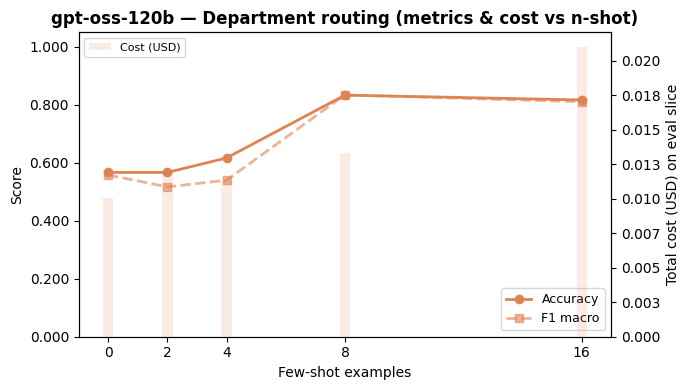

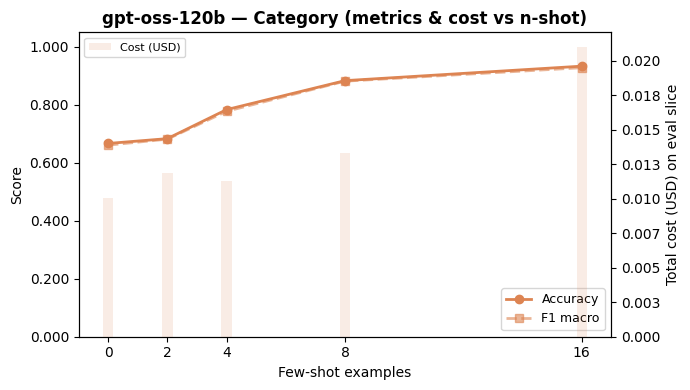

In [25]:
_ = plot_metrics_for_n_shot(ablation_df, best_model=MODEL_TO_EVALUATE)

The accuracy curve shows the quality return on adding examples.

- If accuracy rises steeply from 0 to 2–4 examples and then flattens, 4 examples is probably the right operating point.
- If the curve rises continuously through 8–16 examples, the model is benefiting from more demonstration — but check the cost chart before committing to a high n_shot value.
- A curve that does not improve beyond 0-shot means the prompt is already specific enough and few-shot examples are not adding information.

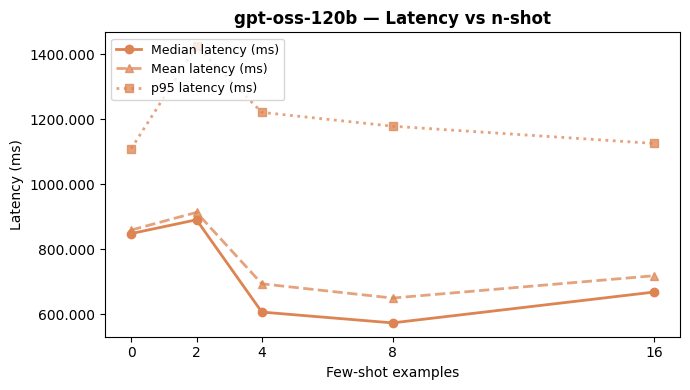

In [26]:
_ = plot_latency_for_n_shots(ablation_df, best_model=MODEL_TO_EVALUATE)

Each additional example adds tokens to every request, which increases both cost and latency.

- Compare the latency at your candidate n_shot value against the Step 8 threshold from Notebook A (p95 <5,000 ms). If adding examples pushes p95 above that threshold, the quality gain may not be worth it.
- Cost grows roughly linearly with n_shot. Calculate the monthly cost delta at your candidate n_shot value and check it against the H6 budget before selecting.

### Run with the best few-shot count

Based on the charts above, pick the `n_shot` value with the best accuracy-to-cost balance and run a full evaluation.

In [27]:
# Choose best n_shot from ablation (priority: department accuracy, then category accuracy).
best_n = 8
best_n_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    few_shot_df=few_shot_pool_df.head(best_n),
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [28]:
best_n_decision = evaluate_decision(best_n_run)
display_mvp_decision(decision=best_n_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.790,0.85
1,Category Accuracy,pass,0.870,0.85
2,Unsafe Auto Route Rate,fail,0.190,0.03
3,Monthly Cost Usd,pass,4.259,1000.00
4,P95 Latency Ms,pass,984.251,5000.00


In [31]:
# Compare the best few-shot run against the baseline run from Step 2.
# This isolates the marginal gain few-shot examples add on top of the default prompt.
_ = display_run_comparison_table(
    baseline=baseline_run,
    new=best_n_run,
    eval_df=df,
    new_label=f"Few-shot best n={best_n}",
    show_all=False,
)

,baseline,Few-shot best n=8,delta_vs_baseline
department_accuracy,0.58,0.79,0.21
category_accuracy,0.67,0.87,0.2
unsafe_auto_route_rate,0.38,0.19,-0.19
monthly_cost_usd,3.372,4.259,0.887
p95_latency_ms,1174.252,984.251,-190.001


### Inspect remaining department mistakes

What does the best few-shot configuration still get wrong? The diagnostic below shows the **department** confusion matrix plus a sample of misrouted messages (category confusion is hidden with `show_category_confusion=False`). Compare these errors to the improved-prompt mistakes in Step 3: if the same pairs recur, neither lever fixed them and they likely need targeted examples or label fixes; if they differ, each lever is trading one kind of error for another.

category_accuracy           0.870
category_f1_macro           0.871
department_accuracy         0.790
department_f1_macro         0.789
exact_route_match_rate      0.760
misroute_rate               0.210
row_count                 100.000


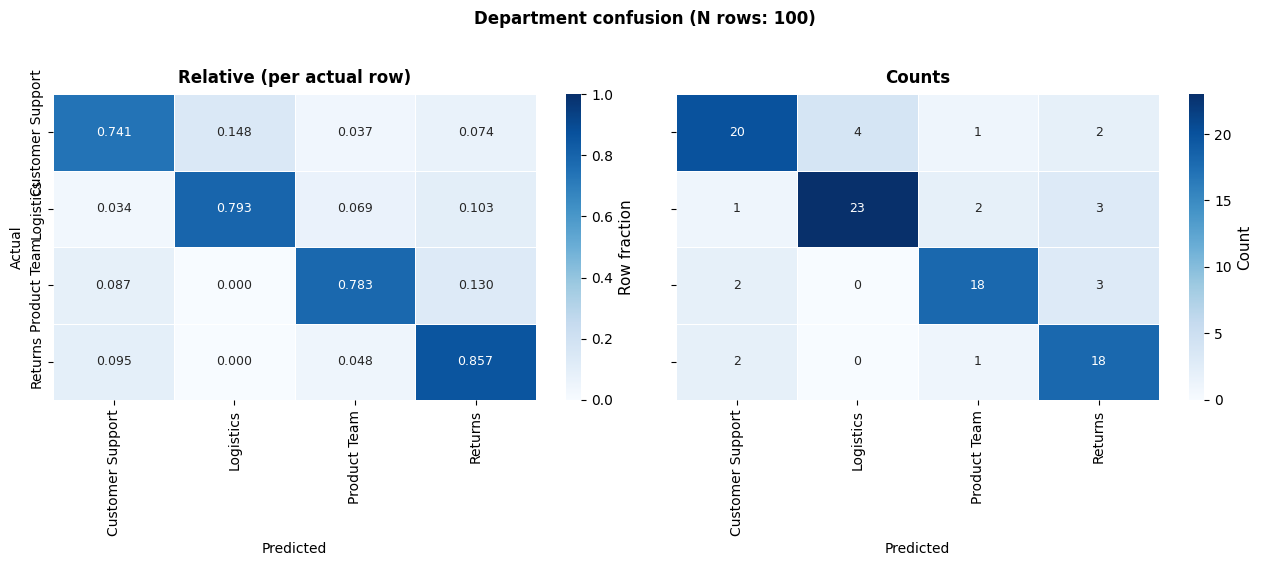

,Request Text,Department,Predicted Department
4,The toaster oven sparked when I plugged it in....,Product Team,Returns
9,Cancel my order immediately. I found it cheape...,Returns,Customer Support
13,Website is crashing on the payment screen.,Product Team,Customer Support
25,Charged for shipping even though it was over $...,Customer Support,Logistics
26,Package in rain rug ruined.,Logistics,Returns
29,Talk to manager now. Support is useless.,Logistics,Customer Support
35,Order canceled without my permission.,Customer Support,Returns
40,Received two lamps only ordered one.,Customer Support,Returns
47,Replacement glass for Orion lantern?,Product Team,Returns
48,Unsubscribe from marketing.,Customer Support,Product Team


In [34]:
# Department confusion + sample mistakes for the best few-shot run
# (category confusion hidden so we focus on department routing).
mistakes = display_evaluation_with_department_mistakes(
    eval_results=best_n_run,
    eval_df=df,
    max_rows=10,
    show_category_confusion=False,
)
mistakes

## Summary

This notebook tested two practical levers against the Notebook A baseline, each measured on the **same default prompt and model** so the comparison is clean:

1. **Prompt improvement (Step 3)** — clearer category definitions, explicit routing rules, and edge-case guidance aim to reduce label confusion, at the cost of a longer prompt.
2. **Few-shot examples (Step 4)** — labeled examples added to the default prompt give the model demonstrations to imitate, at the cost of extra tokens (cost and latency) on every request.

The table below places both approaches next to the baseline on the five MVP dimensions, so you can see which lever moved which metric — and what it cost.

> **Results vary between runs.** Model outputs are not fully deterministic, and these metrics can shift noticeably from one run to the next. Read the table for the **direction and rough size** of each change, not exact values — if two runs are within a couple of points, treat it as a tie and re-run to confirm.


In [40]:
# Side-by-side view of both improvement levers against the baseline.
# Results vary run to run, so read the direction and rough size of each
# difference rather than exact numbers.
summary_runs = {
    "Baseline (default prompt)": baseline_run,
    "Improved prompt (Step 3)": improved_prompt_run,
    f"Few-shot n={best_n} (default prompt, Step 4)": best_n_run,
}
summary_comparison = build_model_comparison_dataframe(df, summary_runs)
summary_comparison

,model,department_accuracy,category_accuracy,unsafe_auto_route_rate,monthly_cost_usd,p95_latency_ms
0,Baseline (default prompt),0.58,0.67,0.38,3.372,1174.252
1,Improved prompt (Step 3),0.73,0.86,0.24,4.661,1601.473
2,"Few-shot n=8 (default prompt, Step 4)",0.79,0.87,0.19,4.259,984.251


How to read the table:

- **Department & category accuracy** — which lever moved routing quality more, and did either clear the 85% department-accuracy target from Notebook A?
- **Unsafe auto-route rate** — did the gains come with better-calibrated confidence, or just more confident mistakes?
- **Monthly cost & p95 latency** — the price of each lever. The improved prompt adds a fixed prompt overhead; few-shot cost grows with the number of examples.

The two levers are independent here, but complementary in practice — you can combine an improved prompt with a few examples. Use the department mistakes tables from Steps 3 and 4 to decide whether the remaining errors justify another iteration, a model change (Notebook A, Step 3), or a review of the gold labels.

If all dimensions now pass, the configuration is ready for workflow integration. If one still fails, decide whether further iteration is warranted — or whether the threshold should be revisited given what you learned about the data.